In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)

Le chargement a nécessité le package : SeuratObject

Le chargement a nécessité le package : sp


Attachement du package : ‘SeuratObject’


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, t



Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
options(repr.plot.width = 24, repr.plot.height = 17, repr.plot.pointsize = 24)

In [4]:
cluster_color <- c("0.0" = "#238b45", "1" = "#cccccc", "2" = "#f768a1", "4" = "#bae1ff", "0.2" = "#bae4b3", "0.3" = "#edf8e9", "0.1" = "#74c476", "3.0" = "#fdf498", "3.1" = "#807dba", "3.2" = "#4a1486", "3.3" = "#ac8fff")

In [5]:
Condition <- c("SE" = "#ff9300", "CTRL" = "#7a81ff")
Time <- c("5" = "#feedde", "10" = "#fdbe85", "20" = "#fd8d3c", "40" = "#d94701")

In [6]:
samples <- c("A_L1_S1" = "#ffffcc", "A_L3_S9" = "#ffeda0", "A_L2_S5" = "#fed976", "A_L4_S13" = "#feb24c", "C_L1_S3" = "#fd8d3c", "C_L4_S15" = "#fc4e2a", "C_L2_S7" = "#e31a1c", "C_L3_S11" = "#b10026", "B_L1_S2" = "#f7fbff", "B_L3_S10" = "#deebf7", "B_L2_S6" = "#c6dbef", "B_L4_S14" = "#9ecae1", "D_L1_S4" = "#6baed6", "D_L4_S16" = "#4292c6", "D_L2_S8" = "#2171b5", "D_L3_S12" = "#084594")

In [7]:
load("/work/project/fragencode/workspace/umr_1141/results/epilepsie/spatial/seurat_obj/whole_clustering_subclustering_Seurat_objects.RData")

In [8]:
seurat_object_whole_clustering@meta.data$cond_time <- paste0(seurat_object_whole_clustering@meta.data$condition, "_", seurat_object_whole_clustering@meta.data$time)

In [9]:
table_cond_by_clusters <- seurat_object_whole_clustering@meta.data %>%
  dplyr::mutate(seurat_custom_clusters = factor(seurat_custom_clusters, levels = c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4"))) %>%
  group_by(cond_time, seurat_custom_clusters) %>%
  summarize(count = n()) %>%
  spread(seurat_custom_clusters, count, fill = 0) %>%
  ungroup() %>%
  mutate(total_cell_count = rowSums(.[c(2:ncol(.))])) %>%
  dplyr::select(c('cond_time', 'total_cell_count', everything())) %>%
  arrange(factor(cond_time, levels = levels(seurat_object_whole_clustering@meta.data$cond_time)))

knitr::kable(table_cond_by_clusters)

`summarise()` has grouped output by 'cond_time'. You can override using the `.groups` argument.




|cond_time | total_cell_count| 0.0| 0.1| 0.2| 0.3|    1|    2| 3.0| 3.1| 3.2| 3.3|   4|
|:---------|----------------:|---:|---:|---:|---:|----:|----:|---:|---:|---:|---:|---:|
|CTRL_10   |             6385| 718| 406| 395| 327| 1684| 1611| 469| 125|  94|  73| 483|
|CTRL_20   |             6103| 728| 470| 401| 245| 1592| 1423| 529| 130| 100|  71| 414|
|CTRL_40   |             6634| 758| 542| 403| 276| 1642| 1754| 503| 122| 105|  80| 449|
|CTRL_5    |             6046| 570| 469| 346| 338| 1541| 1685| 510| 120| 100|  93| 274|
|SE_10     |             5988| 671| 533| 419| 329| 1631| 1389| 473| 113|  82|  68| 280|
|SE_20     |             6365| 716| 441| 475| 289| 1874| 1379| 495| 121| 100|  75| 400|
|SE_40     |             6448| 852| 652| 438| 258| 1659| 1469| 451| 112|  98|  79| 380|
|SE_5      |             6288| 745| 566| 401| 196| 1902| 1279| 605| 117| 101|  71| 305|

In [10]:
table_clusters_by_cond <- seurat_object_whole_clustering@meta.data %>%
  dplyr::rename('cluster' = 'seurat_custom_clusters') %>%
  group_by(cluster, cond_time) %>%
  summarize(count = n()) %>%
  spread(cond_time, count, fill = 0) %>%
  ungroup() %>%
  mutate(total_cell_count = rowSums(.[c(2:ncol(.))])) %>%
  dplyr::select(c('cluster', 'total_cell_count', everything())) %>%
  arrange(factor(cluster, levels = c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4")))

knitr::kable(table_clusters_by_cond)

`summarise()` has grouped output by 'cluster'. You can override using the `.groups` argument.




|cluster | total_cell_count| CTRL_10| CTRL_20| CTRL_40| CTRL_5| SE_10| SE_20| SE_40| SE_5|
|:-------|----------------:|-------:|-------:|-------:|------:|-----:|-----:|-----:|----:|
|0.0     |             5758|     718|     728|     758|    570|   671|   716|   852|  745|
|0.1     |             4079|     406|     470|     542|    469|   533|   441|   652|  566|
|0.2     |             3278|     395|     401|     403|    346|   419|   475|   438|  401|
|0.3     |             2258|     327|     245|     276|    338|   329|   289|   258|  196|
|1       |            13525|    1684|    1592|    1642|   1541|  1631|  1874|  1659| 1902|
|2       |            11989|    1611|    1423|    1754|   1685|  1389|  1379|  1469| 1279|
|3.0     |             4035|     469|     529|     503|    510|   473|   495|   451|  605|
|3.1     |              960|     125|     130|     122|    120|   113|   121|   112|  117|
|3.2     |              780|      94|     100|     105|    100|    82|   100|    98|  10

In [13]:
temp_labels <- seurat_object_whole_clustering@meta.data %>%
  group_by(cond_time) %>%
  tally()

p1 <- table_cond_by_clusters %>%
  dplyr::select(-c('total_cell_count')) %>%
  reshape2::melt(id.vars = 'cond_time') %>%
  dplyr::mutate(cond_time = factor(cond_time, levels = c('CTRL_5', 'CTRL_10', 'CTRL_20', 'CTRL_40', 'SE_5', 'SE_10', 'SE_20', 'SE_40'))) %>%
  ggplot(aes(cond_time, value)) +
  geom_bar(aes(fill = variable), position = 'fill', stat = 'identity') +
  geom_text(
    data = temp_labels,
    aes(x = cond_time, y = Inf, label = paste0('n = ', format(n, big.mark = ',', trim = TRUE)), vjust = -1),
    color = 'black', size = 2
  ) +
  scale_fill_manual(name = 'Cluster', values = cluster_color) +
  scale_y_continuous(name = 'Percentage [%]', labels = scales::percent_format(), expand = c(0.01,0)) +
  coord_cartesian(clip = 'off') +
  theme_bw() +
  theme(
    legend.position = 'left',
    plot.title = element_text(hjust = 0.5),
    text = element_text(size = 16),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.margin = margin(t = 20, r = 0, b = 0, l = 0, unit = 'pt')
  )

temp_labels <- seurat_object_whole_clustering@meta.data %>%
  group_by(seurat_custom_clusters) %>%
  tally() %>%
  dplyr::rename('cluster' = seurat_custom_clusters)

p2 <- table_clusters_by_cond %>%
  dplyr::select(-c('total_cell_count')) %>%
  reshape2::melt(id.vars = 'cluster') %>%
  dplyr::mutate(cluster = factor(cluster, levels = c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4"))) %>%
  dplyr::mutate(variable = factor(variable, levels = c('CTRL_5', 'CTRL_10', 'CTRL_20', 'CTRL_40', 'SE_5', 'SE_10', 'SE_20', 'SE_40'))) %>%
  ggplot(aes(cluster, value)) +
  geom_bar(aes(fill = variable), position = 'fill', stat = 'identity') +
  geom_text(
    data = temp_labels, aes(x = cluster, y = Inf, label = paste0('n = ', format(n, big.mark = ',', trim = TRUE)), vjust = -1),
    color = 'black', size = 2
  ) +
  scale_fill_manual(name = 'Condition', values = colors_dutch) +
  scale_y_continuous(name = 'Percentage [%]', labels = scales::percent_format(), expand = c(0.01,0)) +
  coord_cartesian(clip = 'off') +
  theme_bw() +
  theme(
    legend.position = 'right',
    plot.title = element_text(hjust = 0.5),
    text = element_text(size = 16),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_blank(),
    plot.margin = margin(t = 20, r = 0, b = 0, l = 10, unit = 'pt')
  )

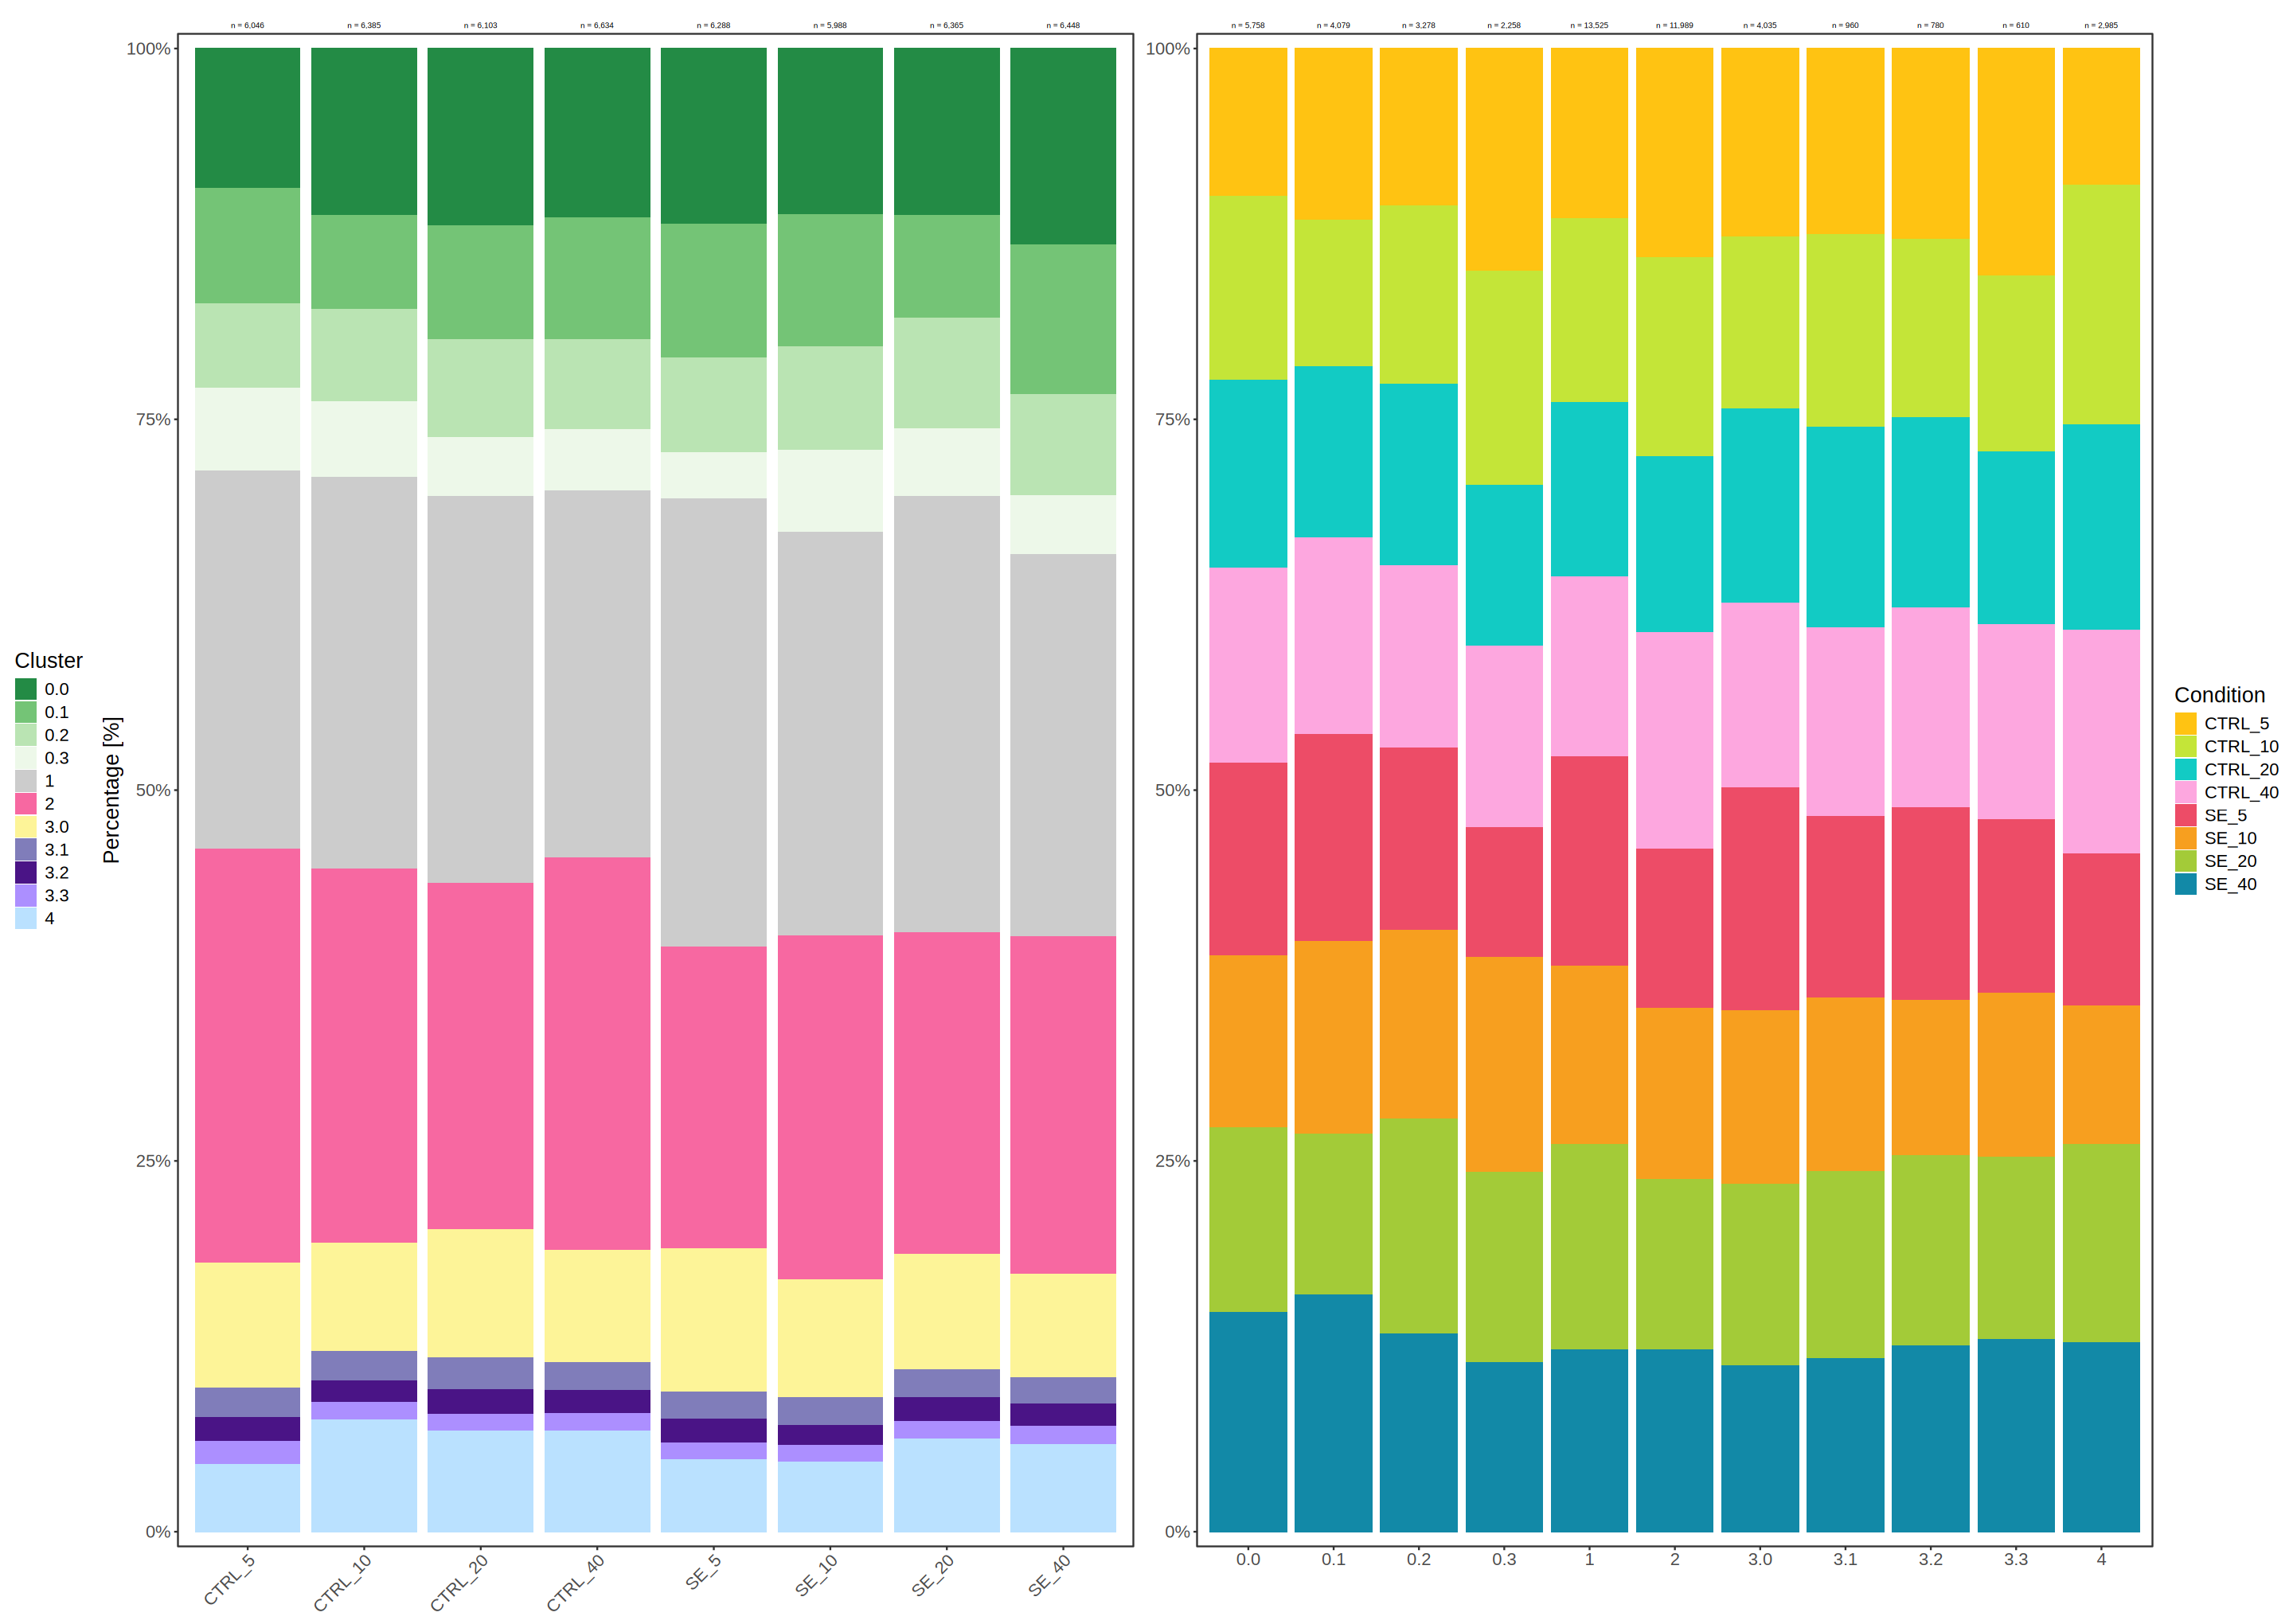

In [14]:
p1 + p2

In [15]:
ggsave(
  '/home/adufour/work/plots/epilepsie/composition_cond_clusters_by_percent.svg',
  p1 + p2 + plot_layout(ncol = 2),
  height = 18,
  width = 40
)

In [8]:
table_sample_by_clusters <- seurat_object_whole_clustering@meta.data %>%
  mutate(seurat_custom_clusters = factor(seurat_custom_clusters, levels = c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4"))) %>%
  group_by(orig.ident, seurat_custom_clusters) %>%
  summarize(count = n()) %>%
  spread(seurat_custom_clusters, count, fill = 0) %>%
  ungroup() %>%
  mutate(total_cell_count = rowSums(.[c(2:ncol(.))])) %>%
  dplyr::select(c('orig.ident', 'total_cell_count', everything())) %>%
  arrange(factor(orig.ident, levels = levels(seurat_object_whole_clustering@meta.data$orig.ident)))

knitr::kable(table_sample_by_clusters)

`summarise()` has grouped output by 'orig.ident'. You can override using the `.groups` argument.




|orig.ident | total_cell_count| 0.0| 0.1| 0.2| 0.3|    1|   2| 3.0| 3.1| 3.2| 3.3|   4|
|:----------|----------------:|---:|---:|---:|---:|----:|---:|---:|---:|---:|---:|---:|
|A_L1_S1    |             3465| 396| 366| 238|  84| 1004| 754| 309|  56|  53|  29| 176|
|A_L2_S5    |             2853| 283| 229| 208| 122|  822| 671| 239|  63|  44|  33| 139|
|A_L3_S9    |             2823| 349| 200| 163| 112|  898| 525| 296|  61|  48|  42| 129|
|A_L4_S13   |             3135| 388| 304| 211| 207|  809| 718| 234|  50|  38|  35| 141|
|B_L1_S2    |             3399| 321| 319| 219| 175|  836| 935| 253|  62|  47|  47| 185|
|B_L2_S6    |             3175| 299| 199| 219| 175|  820| 826| 277|  75|  50|  34| 201|
|B_L3_S10   |             2647| 249| 150| 127| 163|  705| 750| 257|  58|  53|  46|  89|
|B_L4_S14   |             3210| 419| 207| 176| 152|  864| 785| 192|  50|  44|  39| 282|
|C_L1_S3    |             3476| 366| 284| 285| 161| 1045| 734| 290|  76|  61|  46| 128|
|C_L2_S7    |             2900

In [19]:
khi_test <- chisq.test(as.matrix(table_sample_by_clusters[1:2,-c(1,2)]))

In [12]:
table_clusters_by_sample <- seurat_object_whole_clustering@meta.data %>%
  dplyr::rename('cluster' = 'seurat_custom_clusters') %>%
  group_by(cluster, orig.ident) %>%
  summarize(count = n()) %>%
  spread(orig.ident, count, fill = 0) %>%
  ungroup() %>%
  mutate(total_cell_count = rowSums(.[c(2:ncol(.))])) %>%
  dplyr::select(c('cluster', 'total_cell_count', everything())) %>%
  arrange(factor(cluster, levels = levels(seurat_object_whole_clustering@meta.data$seurat_custom_clusters)))

knitr::kable(table_clusters_by_sample)

`summarise()` has grouped output by 'cluster'. You can override using the `.groups` argument.




|cluster | total_cell_count| A_L1_S1| A_L2_S5| A_L3_S9| A_L4_S13| B_L1_S2| B_L2_S6| B_L3_S10| B_L4_S14| C_L1_S3| C_L2_S7| C_L3_S11| C_L4_S15| D_L1_S4| D_L2_S8| D_L3_S12| D_L4_S16|
|:-------|----------------:|-------:|-------:|-------:|--------:|-------:|-------:|--------:|--------:|-------:|-------:|--------:|--------:|-------:|-------:|--------:|--------:|
|0.0     |             5758|     396|     283|     349|      388|     321|     299|      249|      419|     366|     406|      446|      350|     374|     328|      430|      354|
|0.1     |             4079|     366|     229|     200|      304|     319|     199|      150|      207|     284|     273|      379|      157|     334|     261|      281|      136|
|0.2     |             3278|     238|     208|     163|      211|     219|     219|      127|      176|     285|     200|      238|      190|     237|     187|      216|      164|
|0.3     |             2258|      84|     122|     112|      207|     175|     175|      163|     

In [13]:
temp_labels <- seurat_object_whole_clustering@meta.data %>%
  group_by(orig.ident) %>%
  tally()

p1 <- table_sample_by_clusters %>%
  dplyr::select(-c('total_cell_count')) %>%
  reshape2::melt(id.vars = 'orig.ident') %>%
  dplyr::mutate(orig.ident = factor(orig.ident, levels = c("B_L1_S2", "B_L3_S10", "B_L2_S6", "B_L4_S14", "D_L1_S4", "D_L4_S16", "D_L2_S8", "D_L3_S12", "A_L1_S1", "A_L3_S9", "A_L2_S5", "A_L4_S13", "C_L1_S3", "C_L4_S15", "C_L2_S7", "C_L3_S11"))) %>%
  ggplot(aes(orig.ident, value)) +
  geom_bar(aes(fill = variable), position = 'fill', stat = 'identity') +
  geom_text(
    data = temp_labels,
    aes(x = orig.ident, y = Inf, label = paste0('n = ', format(n, big.mark = ',', trim = TRUE)), vjust = -1),
    color = 'black', size = 2
  ) +
  scale_fill_manual(name = 'Cluster', values = cluster_color) +
  scale_y_continuous(name = 'Percentage [%]', labels = scales::percent_format(), expand = c(0.01,0)) +
  coord_cartesian(clip = 'off') +
  theme_bw() +
  theme(
    legend.position = 'left',
    plot.title = element_text(hjust = 0.5),
    text = element_text(size = 16),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.margin = margin(t = 20, r = 0, b = 0, l = 0, unit = 'pt')
  )

temp_labels <- seurat_object_whole_clustering@meta.data %>%
  group_by(seurat_custom_clusters) %>%
  tally() %>%
  dplyr::rename('cluster' = seurat_custom_clusters)

p2 <- table_clusters_by_sample %>%
  dplyr::select(-c('total_cell_count')) %>%
  reshape2::melt(id.vars = 'cluster') %>%
  mutate(cluster = factor(cluster, levels = c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4"))) %>%
  dplyr::mutate(variable = factor(variable, levels = c("B_L1_S2", "B_L3_S10", "B_L2_S6", "B_L4_S14", "D_L1_S4", "D_L4_S16", "D_L2_S8", "D_L3_S12", "A_L1_S1", "A_L3_S9", "A_L2_S5", "A_L4_S13", "C_L1_S3", "C_L4_S15", "C_L2_S7", "C_L3_S11"))) %>%
  ggplot(aes(cluster, value)) +
  geom_bar(aes(fill = variable), position = 'fill', stat = 'identity') +
  geom_text(
    data = temp_labels, aes(x = cluster, y = Inf, label = paste0('n = ', format(n, big.mark = ',', trim = TRUE)), vjust = -1),
    color = 'black', size = 2
  ) +
  scale_fill_manual(name = 'Samples', values = samples) +
  scale_y_continuous(name = 'Percentage [%]', labels = scales::percent_format(), expand = c(0.01,0)) +
  coord_cartesian(clip = 'off') +
  theme_bw() +
  theme(
    legend.position = 'right',
    plot.title = element_text(hjust = 0.5),
    text = element_text(size = 16),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_blank(),
    plot.margin = margin(t = 20, r = 0, b = 0, l = 10, unit = 'pt')
  )

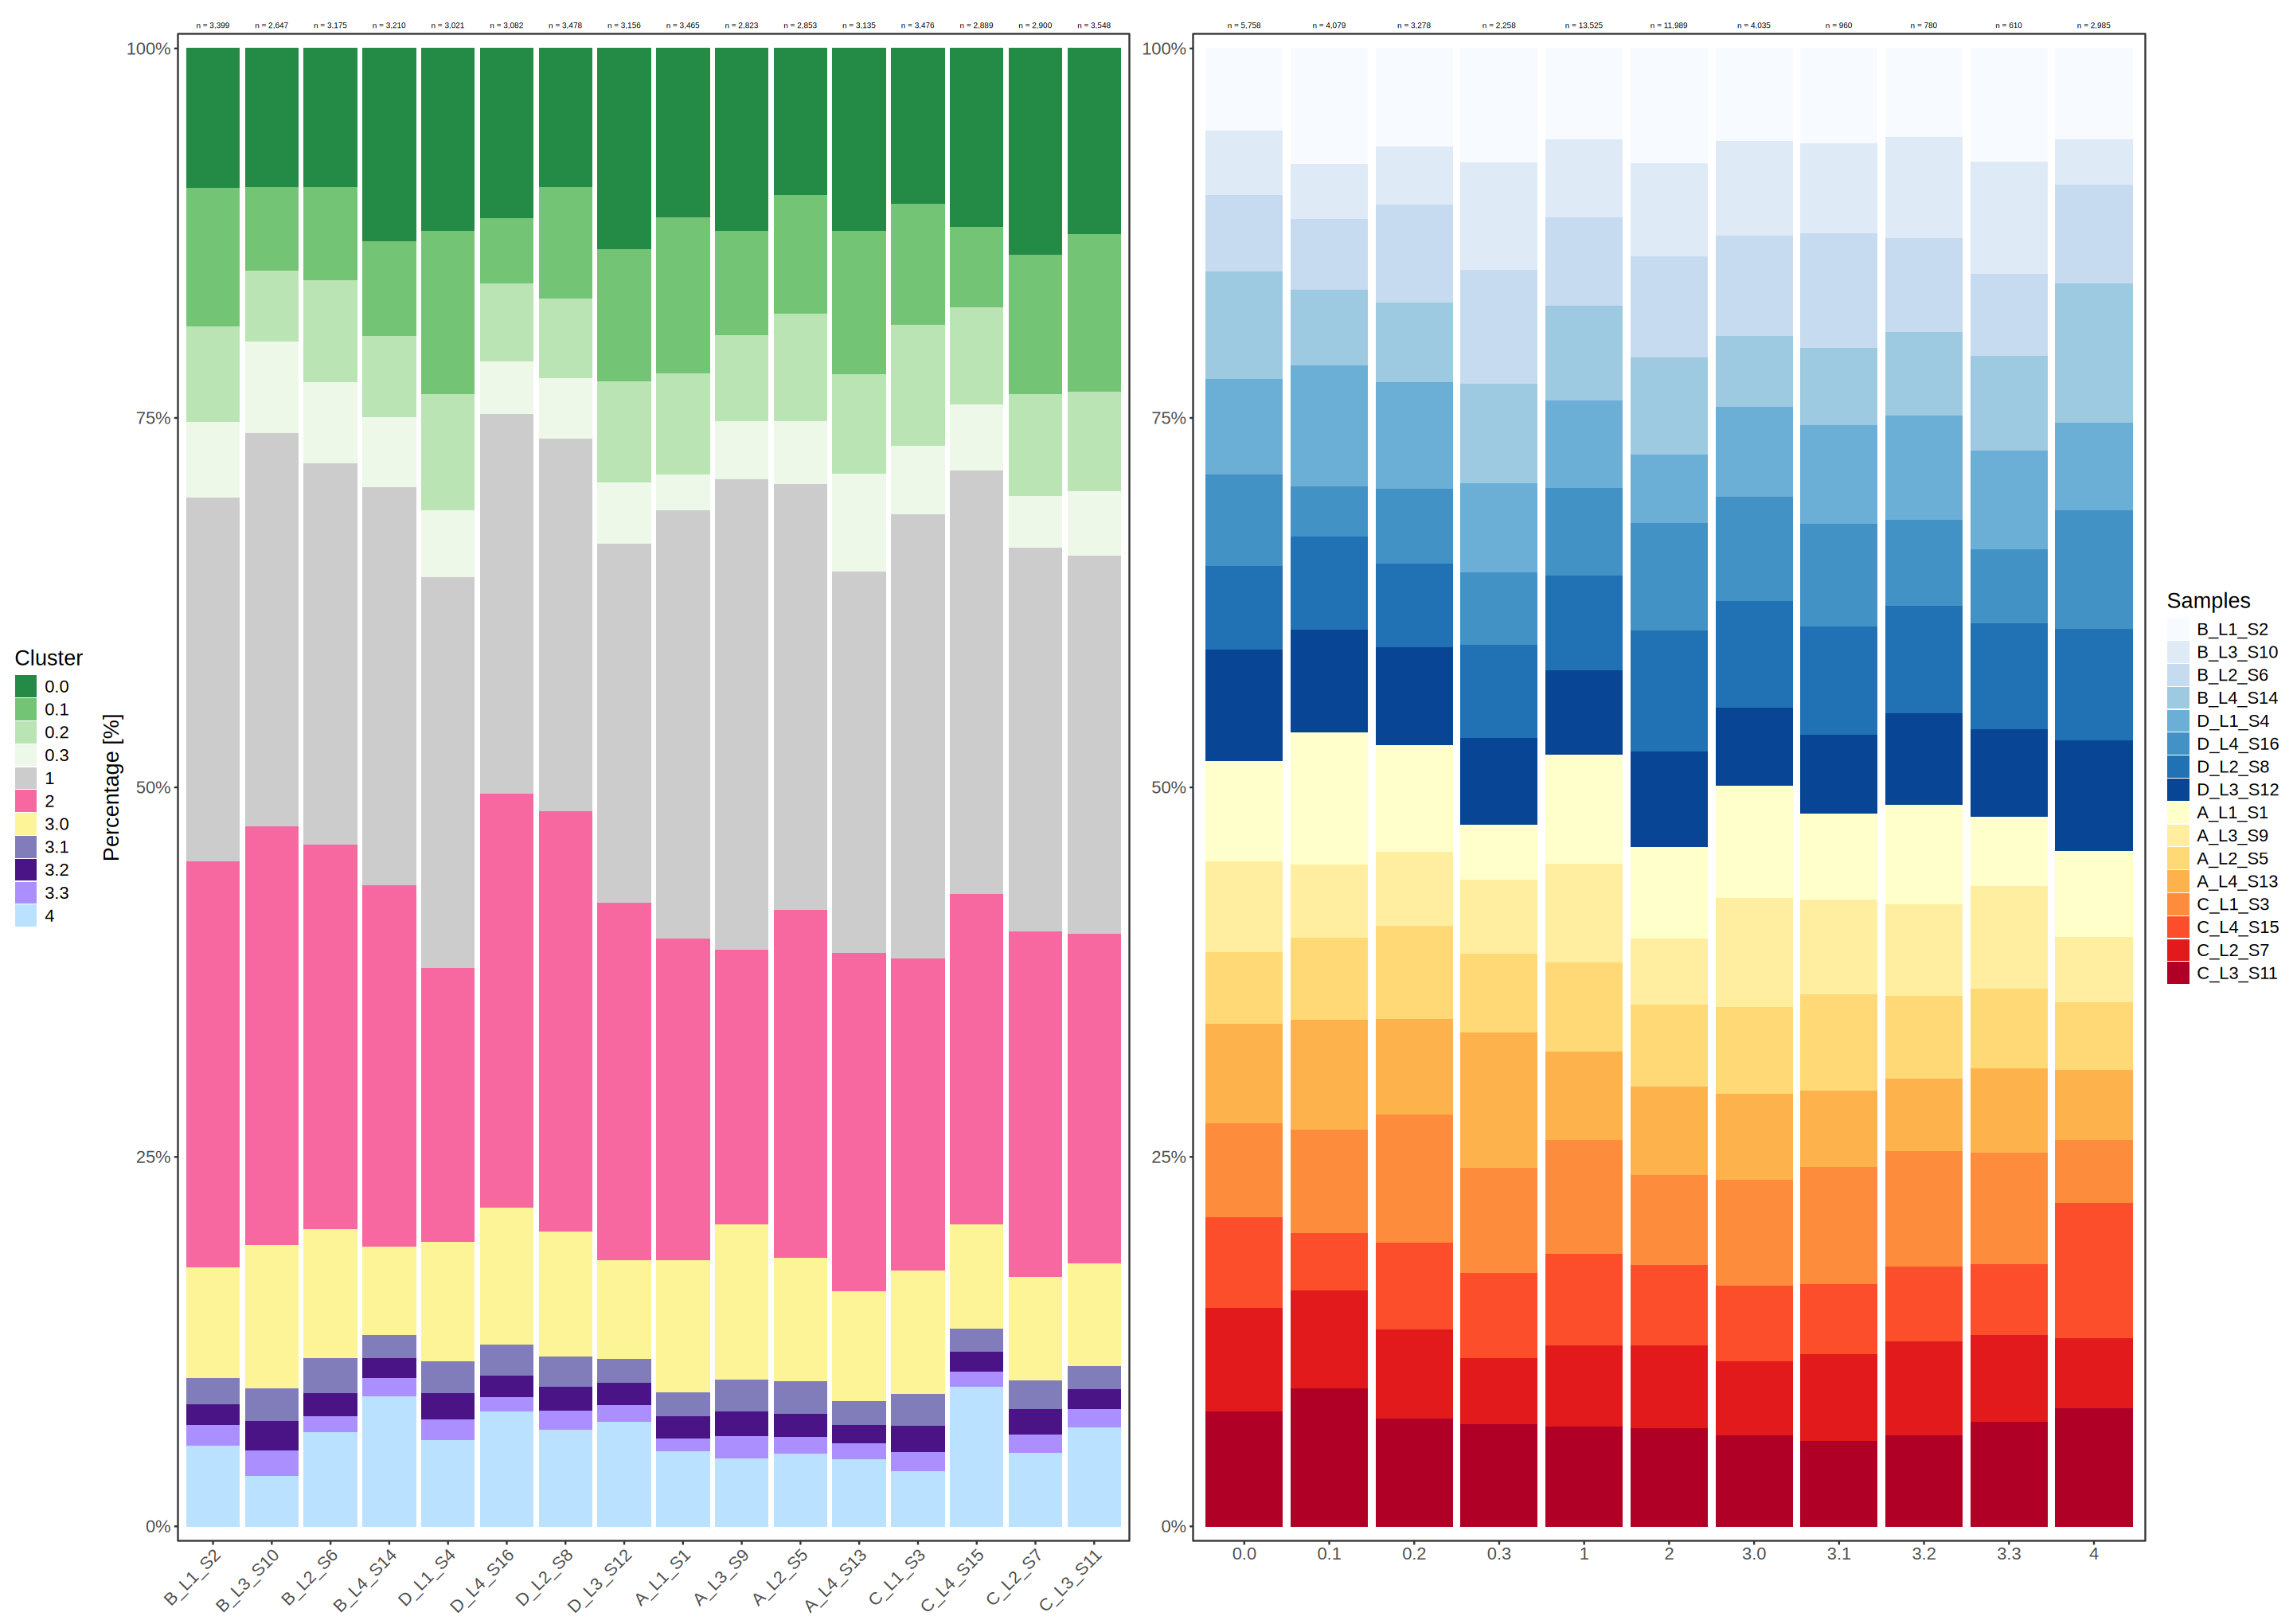

In [14]:
p1 + p2

In [15]:
ggsave(
  '/home/adufour/work/plots/epilepsie/composition_sample_clusters_by_percent.svg',
  p1 + p2 + plot_layout(ncol = 2),
  height = 18,
  width = 40
)